In [1]:
import json
from sklearn.model_selection import train_test_split
import re
from tqdm import tqdm
from datasets import Dataset
import pandas as pd
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import shap
import pickle
import string
from collections import defaultdict
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [4]:
from data_gathering.utils.clean_text import clean_text

In [5]:
with open(project_root + "/params.json", 'r') as f:
    PARAMS = json.load(f)

In [6]:
df = pd.read_csv("themes_from_thesis.csv", sep="\t")

In [7]:
texts = [clean_text(x) for x in df["EXCERPT"]]

In [8]:
len(texts)

169

In [9]:
id2label = {0: 'HIGH', 1: 'MEDIUM', 2: 'LOW'}

In [10]:
# Load your fine-tuned BERT model and tokenizer
model_id = PARAMS["classi_finetune_model"]
model_path = f'{PARAMS["save_model"]}{model_id.split("/")[-1]}_finetuned_16_12'
model_base = PARAMS["classi_finetune_model"]
tokenizer = AutoTokenizer.from_pretrained(model_base)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model = model.to("cuda")
model.eval()

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(256000, 768, padding_idx=0)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (1-21): 21 x ModernBertEncoderLayer(
        (a

In [11]:
def plot_tokens(tokenizer, texts):
    token_lens = []
    for t in texts:
        tokens = tokenizer(t, truncation=False, padding=False)
        token_lens.append(len(tokens["input_ids"]))

    plt.hist(token_lens, bins=100)
    plt.axvline(512, color="r")
    plt.show()

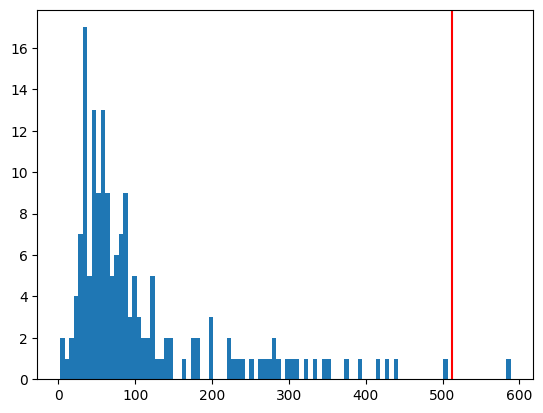

In [12]:
plot_tokens(tokenizer=tokenizer, texts=texts)

In [13]:
preds = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
)


In [14]:
explainer = shap.Explainer(
    preds, seed=42
)

In [15]:
size = 10

In [16]:
# # get shap values in batches

# shap_values = []
# for itr in range(0, len(texts), size):
#     print(f"Processing batch {itr} - {itr+size}")
#     batch_texts = texts[itr:itr+size]
#     batch_shap_values = explainer(batch_texts)
#     with open(f"shap_values_primary/shap_batch_{itr}.pkl", "wb") as f:
#         pickle.dump(batch_shap_values, f)
#     shap_values.append(batch_shap_values)

In [17]:
def get_sorted_shap_files(path_pattern="shap_values_primary/shap_batch_*.pkl"):
    files = glob(path_pattern)

    def extract_number(f):
        match = re.search(r"shap_batch_(\d+)\.pkl", f)
        return int(match.group(1)) if match else -1

    return sorted(files, key=extract_number)

In [18]:
files = get_sorted_shap_files()

In [19]:
all_data = []
all_class_shap = []

for i in files:
    with open(i, "rb") as f:
        batch_sv = pickle.load(f)
    all_class_shap.extend(batch_sv.values)

# to keep the _ token (to join words back)            
for itr in range(0, len(texts), size):
    batch_texts = texts[itr:itr+size]
    for x in batch_texts:
        all_data.append(tokenizer.tokenize(x))

In [20]:
len(all_class_shap), len(all_data), len(texts)

(169, 169, 169)

In [21]:
def merge_tokens(tokens, values):
    merged_tokens = []
    merged_values = []

    current_token = ""
    current_value = None

    for t, v in zip(tokens, values):

        # RoBERTa word start token
        if t.startswith("▁") and t not in string.punctuation:

            # flush previous token
            if current_token != "":
                merged_tokens.append(current_token)
                merged_values.append(current_value)

            current_token = t[1:]  # remove _
            current_value = v.copy()

        else:
            if t not in string.punctuation:
                # continuation of same word
                current_token += t
                current_value += v

    # flush last token
    if current_token:
        merged_tokens.append(current_token)
        merged_values.append(current_value)

    return merged_tokens, np.array(merged_values)

In [22]:
def group_values(tokens, values, group=2):
    paired_tokens = []
    paired_values = []

    for i in range(0, len(tokens), group):
        pair_tokens = tokens[i-group:i+group]
        pair_values = values[i-group:i+group]

        # join tokens with space
        paired_tokens.append(" ".join(pair_tokens))

        # combine values (sum, mean, etc.)
        paired_values.append(np.sum(pair_values, axis=0))

    return paired_tokens, np.array(paired_values)

In [33]:
class_contribs = [defaultdict(list) for _ in range(3)]
class_contexts = [defaultdict(list) for _ in range(3)]
group = 2
for d, sv in zip(all_data, all_class_shap):
    merged_tokens, merged_values = merge_tokens(d, sv)
    merged_tokens, merged_values = group_values(merged_tokens, merged_values, group)
    for i, token in enumerate(merged_tokens):
        for c in range(3):
            # get context around max value words 
            context = " ".join(
                            merged_tokens[max(i - group, 0): i - 1]
                            + [f"[[{merged_tokens[i]}]]"]
                            + merged_tokens[i + 1: i + group]
                    )
            
            class_contribs[c][token].append(merged_values[i, c])
            class_contexts[c][token].append(context)          
            

In [34]:
top_k = 10

agg = []

for c in range(3):
    token_scores = {
        token: np.mean(vals)
        for token, vals in class_contribs[c].items()
    }
    agg.append(token_scores)
    

for c in range(3):

    print(f"\nTop words for class {id2label[c]}:")

    sorted_tokens = sorted(
        [(token, score) for token, score in agg[c].items() if score > 0],
        key=lambda x: x[1],
        reverse=True
    )

    for token, score in sorted_tokens[:top_k]:

        # choose one example context
        example_context = class_contexts[c][token][:3]

        print(f"\n{token}: {score:.4f}")
        examples = "\n    ".join(example_context)
        print(f"    {examples}")


Top words for class HIGH:

with deceptive shallows and: 0.2124
    by a treacherous harbour [[with deceptive shallows and]] shallows and uncertain seas

shallows and uncertain seas: 0.2124
    treacherous harbour with deceptive [[shallows and uncertain seas]]

either killing or enslaving: 0.1920
    closed Egypt to strangers [[either killing or enslaving]] or enslaving any who

ca 1 BCE The: 0.1763
    [[ca 1 BCE The]] BCE The mouths have

lighters only on account: 0.1532
    admitting large vessels but [[lighters only on account]] on account of the

For Alexandria is approached: 0.1416
    [[For Alexandria is approached]] is approached by a

side of the river: 0.1273
    the shallows to their [[side of the river]]

treacherous harbour with deceptive: 0.1239
    is approached by a [[treacherous harbour with deceptive]] with deceptive shallows and

or enslaving any who: 0.1220
    to strangers either killing [[or enslaving any who]] any who touched its

to their side of: 0.1214
    gro

In [25]:
top_k = 10

agg = []

for c in range(3):
    token_scores = {
        token: np.mean(vals)
        for token, vals in class_contribs[c].items()
    }
    agg.append(token_scores)
    

for c in range(3):

    print(f"\nTop words for class {id2label[c]}:")

    sorted_tokens = sorted(
        [(token, score) for token, score in agg[c].items() if score < 0],
        key=lambda x: x[1],
        reverse=False
    )

    for token, score in sorted_tokens[:top_k]:

        # choose one example context
        example_context = class_contexts[c][token][:3]

        print(f"\n{token}: {score:.4f}")
        examples = "\n    ".join(example_context)
        print(f"    {examples}")


Top words for class HIGH:

his orders with promptness: -0.0509
    been dispatched carried out carried out his orders [[his orders with promptness]] with promptness and entered and entered the harbour

with promptness and entered: -0.0372
    carried out his orders his orders with promptness [[with promptness and entered]] and entered the harbour the harbour of the

vessels from Chios and: -0.0168
    Lesbos Sigrion where cargo where cargo vessels from [[vessels from Chios and]] Chios and Geraistos and Geraistos and Malea usually

Chios and Geraistos and: -0.0158
    where cargo vessels from vessels from Chios and [[Chios and Geraistos and]] Geraistos and Malea usually Malea usually put in

priests said first of: -0.0085
     He (the priests said [[priests said first of]] first of all set all set out with

capit quale est vectigal: -0.0060
    ex quibus vectigal fiscus vectigal fiscus capit quale [[capit quale est vectigal]] est vectigal portus vel portus vel venalium rerum

Schedia i